In [1]:
# ==========================
# BLOCK 1: Imports & Config
# ==========================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.inspection import permutation_importance

from pygam import LinearGAM, s
from functools import reduce
import operator

from xgboost import XGBRegressor

# For ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap
import os
import joblib
import pickle  # optional

RANDOM_STATE = 42
TEST_SIZE = 0.2          # last 20% of time as final test set
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [ ]:
# ==============================
# BLOCK 2: Load & Time Split
# ==============================
df = pd.read_csv("/Users/arup/Documents/ug_thesis/data_normalized.csv")
# expected columns: ['time', 'latitude', 'longitude', 'uo', 'vo', 'kd', 'fe', 'no3', 'po4', 'si', 'o2', 'ph', 'so', 'spco2', 'thetao', 'wo', 'chl']

FEATURES = ['uo', 'vo', 'kd', 'fe', 'no3', 'po4', 'si', 'o2', 'ph', 'so', 'spco2', 'thetao', 'wo']
TARGET = 'chl'

# parse time, drop missing, sort by time
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.dropna(subset=['time', 'latitude', 'longitude'] + FEATURES + [TARGET])
df = df.sort_values('time').reset_index(drop=True)

# time-based train/test split: last 20% as test
n_samples = len(df)
test_size_int = max(1, int(np.floor(TEST_SIZE * n_samples)))
test_start_idx = n_samples - test_size_int

train_idx = np.arange(0, test_start_idx)
test_idx = np.arange(test_start_idx, n_samples)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

X_train_full = df_train[FEATURES].values   # full feature matrix for BAS
y_train = df_train[TARGET].values

X_test_full  = df_test[FEATURES].values
y_test  = df_test[TARGET].values

df_coords_train = df_train[['time', 'latitude', 'longitude']].copy()


In [3]:
# ===========================================
# BLOCK 3: Spatio-Temporal Blocked CV
# ===========================================
class SpatioTemporalBlockSplit:
    """
    Spatio-temporal cross-validator.

    - Works on data already sorted by time.
    - Uses forward-chaining over time (no future -> past leakage).
    - Adds simple spatial blocking using latitude/longitude bins.
    """

    def __init__(
        self,
        df_coords,
        n_splits=5,
        time_col='time',
        lat_col='latitude',
        lon_col='longitude',
        n_lat_blocks=4,
        n_lon_blocks=4,
        random_state=42
    ):
        self.df_coords = df_coords.reset_index(drop=True)
        self.n_splits = n_splits
        self.time_col = time_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.n_lat_blocks = n_lat_blocks
        self.n_lon_blocks = n_lon_blocks
        self.random_state = random_state

        self.df_coords[self.time_col] = pd.to_datetime(
            self.df_coords[self.time_col], errors='coerce'
        )

        self._compute_blocks()

    def _compute_blocks(self):
        lat = self.df_coords[self.lat_col].values
        lon = self.df_coords[self.lon_col].values

        lat_min, lat_max = lat.min(), lat.max()
        lon_min, lon_max = lon.min(), lon.max()

        lat_edges = np.linspace(lat_min, lat_max, self.n_lat_blocks + 1)
        lon_edges = np.linspace(lon_min, lon_max, self.n_lon_blocks + 1)

        lat_bin = np.digitize(lat, lat_edges) - 1
        lon_bin = np.digitize(lon, lon_edges) - 1

        lat_bin = np.clip(lat_bin, 0, self.n_lat_blocks - 1)
        lon_bin = np.clip(lon_bin, 0, self.n_lon_blocks - 1)

        self.block_ids = lat_bin * self.n_lon_blocks + lon_bin

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X=None, y=None, groups=None):
        n_samples = len(self.df_coords)
        indices = np.arange(n_samples)
        rng = np.random.RandomState(self.random_state)

        for k in range(1, self.n_splits + 1):
            test_start = int(n_samples * k / (self.n_splits + 1))
            test_end = int(n_samples * (k + 1) / (self.n_splits + 1)) if k < self.n_splits else n_samples

            test_time_idx = indices[test_start:test_end]
            train_time_idx = indices[:test_start]

            test_blocks_unique = np.unique(self.block_ids[test_time_idx])

            if len(test_blocks_unique) > 1:
                n_test_blocks = max(1, len(test_blocks_unique) // 2)
                test_blocks = rng.choice(test_blocks_unique, size=n_test_blocks, replace=False)
            else:
                test_blocks = test_blocks_unique

            is_test_block = np.isin(self.block_ids, test_blocks)

            test_mask = np.zeros_like(indices, dtype=bool)
            test_mask[test_time_idx] = True
            test_indices = indices[test_mask & is_test_block]

            train_mask = np.zeros_like(indices, dtype=bool)
            train_mask[train_time_idx] = True
            train_mask &= ~np.isin(self.block_ids, test_blocks)
            train_indices = indices[train_mask]

            if len(train_indices) == 0 or len(test_indices) == 0:
                continue

            yield train_indices, test_indices

cv_st = SpatioTemporalBlockSplit(
    df_coords=df_coords_train,
    n_splits=CV_FOLDS,
    time_col='time',
    lat_col='latitude',
    lon_col='longitude',
    n_lat_blocks=4,
    n_lon_blocks=4,
    random_state=RANDOM_STATE
)


In [4]:
# ===========================================
# BLOCK 4: BAS Feature Selection
# ===========================================
def bas_fs_objective(x, X, y, cv, model_builder, threshold=0.5):
    """
    x: vector in [0,1]^n_features
    threshold: value above which a feature is 'selected'

    Objective to MINIMIZE = - mean CV R2
    """
    mask = x > threshold
    if mask.sum() == 0:
        return 1e9  # penalize empty set

    X_sel = X[:, mask]
    model = model_builder()

    scores = cross_val_score(
        model,
        X_sel,
        y,
        cv=cv,
        scoring='r2',
        n_jobs=-1
    )
    mean_r2 = scores.mean()
    return -mean_r2


def bas_feature_selection(
    X, y, cv, model_builder,
    n_iter=30,
    delta=0.2,
    step_size=0.2,
    threshold=0.5,
    random_state=42
):
    """
    Simple Beetle Antenna Search for feature selection.

    Returns:
        best_mask (bool array),
        best_r2 (mean CV R2 of best subset)
    """
    rng = np.random.RandomState(random_state)
    n_features = X.shape[1]

    x = rng.rand(n_features)  # init in [0,1]
    best_x = x.copy()
    best_obj = bas_fs_objective(x, X, y, cv, model_builder, threshold)
    curr_step = step_size

    print("\n=== BAS Feature Selection ===")
    for it in range(1, n_iter + 1):
        d = rng.randn(n_features)
        d /= np.linalg.norm(d) + 1e-12

        x_left = np.clip(x - delta * d, 0.0, 1.0)
        x_right = np.clip(x + delta * d, 0.0, 1.0)

        obj_left = bas_fs_objective(x_left, X, y, cv, model_builder, threshold)
        obj_right = bas_fs_objective(x_right, X, y, cv, model_builder, threshold)

        if obj_right < obj_left:
            x_new = np.clip(x + curr_step * d, 0.0, 1.0)
            obj_new = bas_fs_objective(x_new, X, y, cv, model_builder, threshold)
        else:
            x_new = np.clip(x - curr_step * d, 0.0, 1.0)
            obj_new = bas_fs_objective(x_new, X, y, cv, model_builder, threshold)

        x = x_new

        if obj_new < best_obj:
            best_obj = obj_new
            best_x = x_new.copy()

        curr_step *= 0.95

        print(f"Iter {it:02d}/{n_iter} | mean CV R2 = {-obj_new:.4f}")

    best_mask = best_x > threshold
    best_r2 = -best_obj
    return best_mask, best_r2


def rf_builder():
    return RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

bas_mask, bas_best_r2 = bas_feature_selection(
    X_train_full,
    y_train,
    cv=cv_st,
    model_builder=rf_builder,
    n_iter=30,
    delta=0.2,
    step_size=0.2,
    threshold=0.5,
    random_state=RANDOM_STATE
)

print("\nBAS best CV R2:", bas_best_r2)
print("BAS selected features:")
for f, keep in zip(FEATURES, bas_mask):
    print(f"  {f}: {'KEEP' if keep else 'DROP'}")

SELECTED_FEATURES = [f for f, keep in zip(FEATURES, bas_mask) if keep]
print("\nSELECTED_FEATURES via BAS:", SELECTED_FEATURES)

# Build design matrices with selected features
X_train = df_train[SELECTED_FEATURES].values
X_test  = df_test[SELECTED_FEATURES].values



=== BAS Feature Selection ===
Iter 01/30 | mean CV R2 = 0.9382
Iter 02/30 | mean CV R2 = 0.9382
Iter 03/30 | mean CV R2 = 0.9382
Iter 04/30 | mean CV R2 = 0.9382
Iter 05/30 | mean CV R2 = 0.9382
Iter 06/30 | mean CV R2 = 0.9387
Iter 07/30 | mean CV R2 = 0.9387
Iter 08/30 | mean CV R2 = 0.9387
Iter 09/30 | mean CV R2 = 0.9387
Iter 10/30 | mean CV R2 = 0.9387
Iter 11/30 | mean CV R2 = 0.9387
Iter 12/30 | mean CV R2 = 0.9387
Iter 13/30 | mean CV R2 = 0.9387
Iter 14/30 | mean CV R2 = 0.9387
Iter 15/30 | mean CV R2 = 0.9387
Iter 16/30 | mean CV R2 = 0.9387
Iter 17/30 | mean CV R2 = 0.9387
Iter 18/30 | mean CV R2 = 0.9387
Iter 19/30 | mean CV R2 = 0.9387
Iter 20/30 | mean CV R2 = 0.9387
Iter 21/30 | mean CV R2 = 0.9387
Iter 22/30 | mean CV R2 = 0.9387
Iter 23/30 | mean CV R2 = 0.9387
Iter 24/30 | mean CV R2 = 0.9387
Iter 25/30 | mean CV R2 = 0.9387
Iter 26/30 | mean CV R2 = 0.9387
Iter 27/30 | mean CV R2 = 0.9387
Iter 28/30 | mean CV R2 = 0.9387
Iter 29/30 | mean CV R2 = 0.9387
Iter 30/30 |

In [5]:
# ==========================
# BLOCK 5: Helpers
# ==========================
def print_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:25s} | R2 = {r2:.4f} | RMSE = {rmse:.4f}")
    return r2, rmse

def cv_r2_score(model, X, y, cv, is_gam=False, scaler=None):
    """
    Mean/std R2 using provided CV splitter.
    For GAM: pass model as a callable that builds a new instance.
    """
    scores = []
    for train_idx, val_idx in cv.split(X):
        Xtr, Xval = X[train_idx], X[val_idx]
        ytr, yval = y[train_idx], y[val_idx]

        if scaler is not None:
            scaler_fold = StandardScaler()
            Xtr = scaler_fold.fit_transform(Xtr)
            Xval = scaler_fold.transform(Xval)

        if is_gam:
            gam = model()
            gam.fit(Xtr, ytr)
            pred = gam.predict(Xval)
        else:
            m = model.__class__(**model.get_params())
            m.fit(Xtr, ytr)
            pred = m.predict(Xval)

        scores.append(r2_score(yval, pred))

    scores = np.array(scores)
    return scores.mean(), scores.std()

def plot_perm_importance(result, feature_names, title):
    means = result.importances_mean
    stds = result.importances_std
    idx = np.argsort(means)[::-1]

    plt.figure(figsize=(6, 4))
    plt.bar(range(len(feature_names)), means[idx], yerr=stds[idx], alpha=0.8)
    plt.xticks(range(len(feature_names)), [feature_names[i] for i in idx], rotation=45)
    plt.ylabel("Decrease in R2")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [6]:
# ==========================
# BLOCK 6: GAM
# ==========================
n_terms = len(SELECTED_FEATURES)
terms = reduce(operator.add, (s(i) for i in range(n_terms)))

gam = LinearGAM(terms).fit(X_train, y_train)
y_pred_gam = gam.predict(X_test)
print_metrics("GAM (test, BAS features)", y_test, y_pred_gam)

gam_cv_mean, gam_cv_std = cv_r2_score(
    lambda: LinearGAM(terms),
    X_train, y_train,
    cv=cv_st,
    is_gam=True
)
print(f"GAM CV R2 (spatio-temporal, BAS features): {gam_cv_mean:.4f} ± {gam_cv_std:.4f}")


GAM (test, BAS features)  | R2 = 0.9346 | RMSE = 1.0012
GAM CV R2 (spatio-temporal, BAS features): 0.8442 ± 0.1388


In [7]:
# ==========================
# BLOCK 7: RF & XGB
# ==========================
# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print_metrics("RandomForest (test, BAS features)", y_test, y_pred_rf)

rf_cv_mean = cross_val_score(
    rf,
    X_train, y_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"RandomForest CV R2 (spatio-temporal, BAS features): {rf_cv_mean:.4f}")

# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb.predict(X_test)
print_metrics("XGBoost (test, BAS features)", y_test, y_pred_xgb)

xgb_cv_mean = cross_val_score(
    xgb,
    X_train, y_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"XGBoost CV R2 (spatio-temporal, BAS features): {xgb_cv_mean:.4f}")


RandomForest (test, BAS features) | R2 = 0.9563 | RMSE = 0.8186
RandomForest CV R2 (spatio-temporal, BAS features): 0.9387
XGBoost (test, BAS features) | R2 = 0.9511 | RMSE = 0.8660
XGBoost CV R2 (spatio-temporal, BAS features): 0.9264


In [8]:
# ==========================
# BLOCK 8: Huber Robust LR
# ==========================
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_train_scaled, y_train)
y_pred_huber = huber.predict(X_test_scaled)
print_metrics("Huber RobustLR (test, BAS features)", y_test, y_pred_huber)

huber_pipe = make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, max_iter=1000))
huber_cv_mean = cross_val_score(
    huber_pipe,
    X_train, y_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"Huber CV R2 (spatio-temporal, BAS features): {huber_cv_mean:.4f}")


Huber RobustLR (test, BAS features) | R2 = 0.6555 | RMSE = 2.2978
Huber CV R2 (spatio-temporal, BAS features): 0.7103


Epoch 1/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3038 - mse: 1.3038 - val_loss: 0.6032 - val_mse: 0.6032
Epoch 2/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7216 - mse: 0.7216 - val_loss: 0.4851 - val_mse: 0.4851
Epoch 3/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6145 - mse: 0.6145 - val_loss: 0.3821 - val_mse: 0.3821
Epoch 4/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5574 - mse: 0.5574 - val_loss: 0.5506 - val_mse: 0.5506
Epoch 5/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5584 - mse: 0.5584 - val_loss: 0.5769 - val_mse: 0.5769
Epoch 6/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4930 - mse: 0.4930 - val_loss: 0.5491 - val_mse: 0.5491
Epoch 7/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4854 - mse: 0.4854 - val_loss: 0.4252 - val_mse: 0.4252
Epoch 8/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4844 - mse: 0.4844 - val_loss: 0.4805 - val_mse: 0.4805
Epoch 9/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

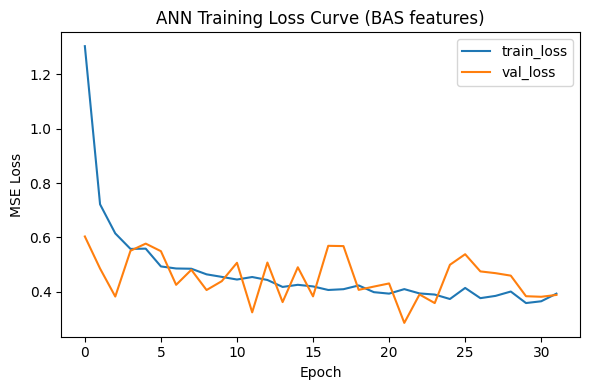

In [9]:
# ==========================
# BLOCK 9: ANN
# ==========================
scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train)
X_test_ann = scaler_ann.transform(X_test)

def build_ann(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model

ann = build_ann(X_train_ann.shape[1])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train_ann, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=256,
    callbacks=[es],
    verbose=1
)

y_pred_ann = ann.predict(X_test_ann).ravel()
print_metrics("ANN (test, BAS features)", y_test, y_pred_ann)

def ann_cv_r2(X, y, cv):
    scores = []
    for train_idx, val_idx in cv.split(X):
        Xtr, Xv = X[train_idx], X[val_idx]
        ytr, yv = y[train_idx], y[val_idx]

        sc = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr)
        Xv_s = sc.transform(Xv)

        m = build_ann(Xtr_s.shape[1])
        m.fit(
            Xtr_s, ytr,
            epochs=100,
            batch_size=256,
            validation_split=0.1,
            callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
            verbose=0
        )
        pred = m.predict(Xv_s).ravel()
        scores.append(r2_score(yv, pred))

    scores = np.array(scores)
    return scores.mean(), scores.std()

ann_cv_mean, ann_cv_std = ann_cv_r2(X_train, y_train, cv=cv_st)
print(f"ANN CV R2 (spatio-temporal, BAS features, {CV_FOLDS}-fold): {ann_cv_mean:.4f} ± {ann_cv_std:.4f}")

# ANN loss curve
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training Loss Curve (BAS features)')
plt.legend()
plt.tight_layout()
plt.show()



Model summary (BAS-selected features)  [CV R2, Test R2]:
GAM          | CV R2 = 0.8442 | Test R2 = 0.9346
RandomForest | CV R2 = 0.9387 | Test R2 = 0.9563
XGBoost      | CV R2 = 0.9264 | Test R2 = 0.9511
Huber        | CV R2 = 0.7103 | Test R2 = 0.6555
ANN          | CV R2 = 0.8484 | Test R2 = 0.9503


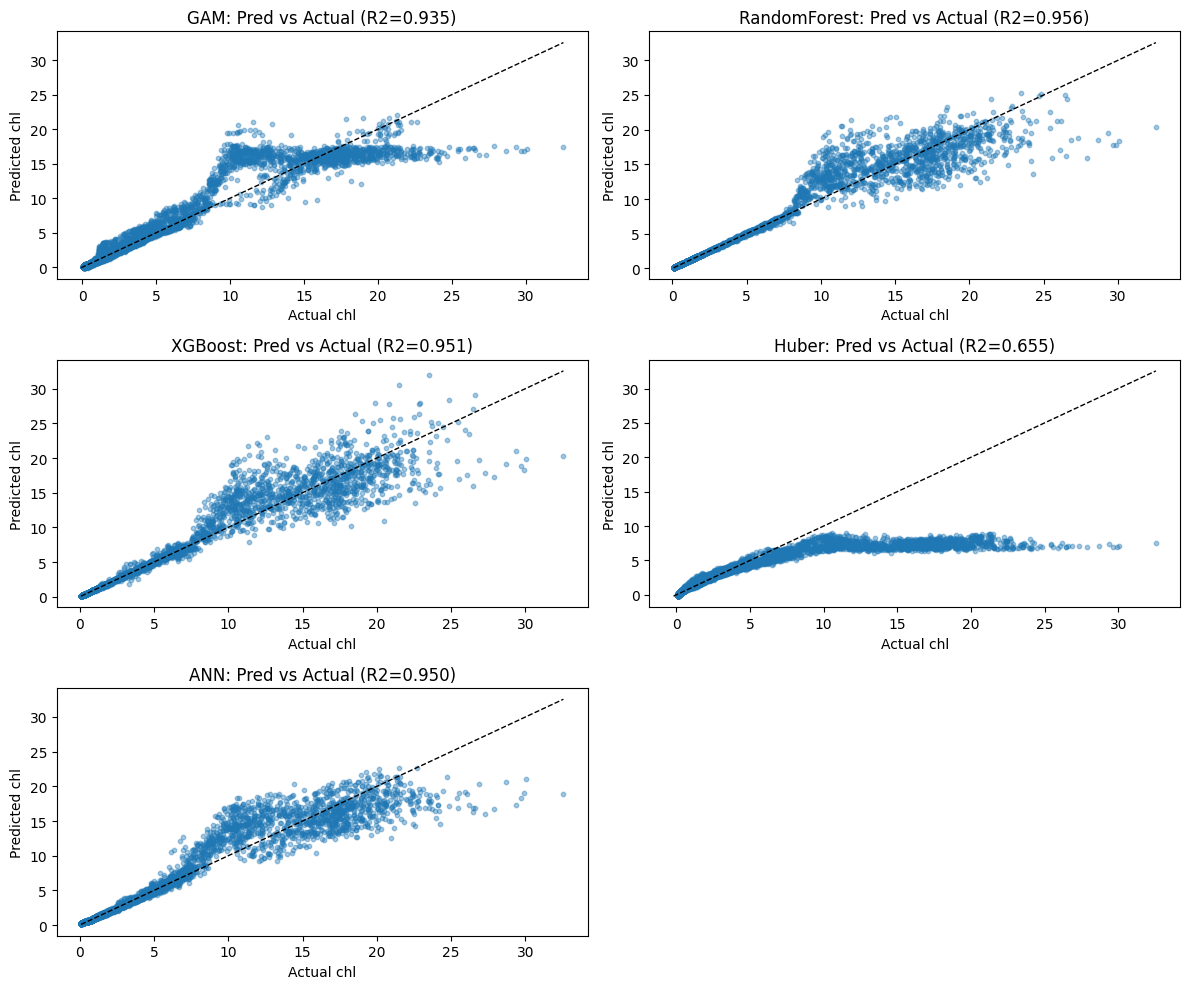

In [10]:
# ==========================
# BLOCK 10: Summary & Plots
# ==========================
models_info = [
    ("GAM",          gam_cv_mean,   r2_score(y_test, y_pred_gam)),
    ("RandomForest", rf_cv_mean,    r2_score(y_test, y_pred_rf)),
    ("XGBoost",      xgb_cv_mean,   r2_score(y_test, y_pred_xgb)),
    ("Huber",        huber_cv_mean, r2_score(y_test, y_pred_huber)),
    ("ANN",          ann_cv_mean,   r2_score(y_test, y_pred_ann)),
]

print("\nModel summary (BAS-selected features)  [CV R2, Test R2]:")
for name, cv_r2, test_r2 in models_info:
    print(f"{name:12s} | CV R2 = {cv_r2:.4f} | Test R2 = {test_r2:.4f}")

plt.figure(figsize=(12, 10))
model_preds = {
    'GAM':          y_pred_gam,
    'RandomForest': y_pred_rf,
    'XGBoost':      y_pred_xgb,
    'Huber':        y_pred_huber,
    'ANN':          y_pred_ann
}

i = 1
for name, preds in model_preds.items():
    plt.subplot(3, 2, i)
    plt.scatter(y_test, preds, s=10, alpha=0.4)
    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    plt.xlabel("Actual chl")
    plt.ylabel("Predicted chl")
    plt.title(f"{name}: Pred vs Actual (R2={r2_score(y_test, preds):.3f})")
    i += 1

plt.tight_layout()
plt.show()



=== Permutation Importance on Test Set (BAS-selected features) ===

RandomForest Permutation Importance (mean decrease in R2):
   kd: 1.5612 ± 0.0100
   so: 0.0490 ± 0.0011
   ph: 0.0342 ± 0.0009
thetao: 0.0225 ± 0.0015
   wo: 0.0139 ± 0.0012
   o2: 0.0092 ± 0.0006
   vo: 0.0025 ± 0.0003


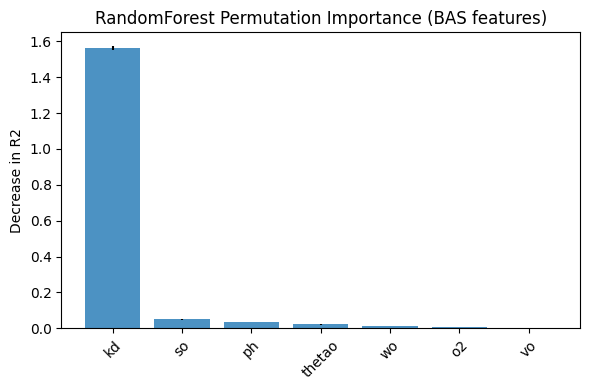


XGBoost Permutation Importance (mean decrease in R2):
   kd: 1.4472 ± 0.0098
   so: 0.0505 ± 0.0013
   ph: 0.0475 ± 0.0013
   o2: 0.0266 ± 0.0009
thetao: 0.0211 ± 0.0018
   wo: 0.0204 ± 0.0016
   vo: 0.0073 ± 0.0009


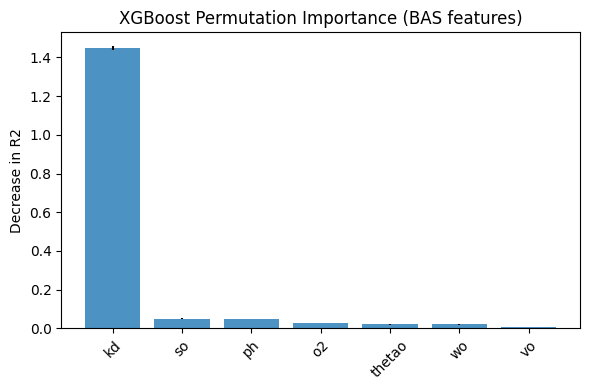


GAM Permutation Importance (mean decrease in R2):
   kd: 1.4930 ± 0.0101
   so: 0.0307 ± 0.0005
   o2: 0.0070 ± 0.0003
   ph: 0.0065 ± 0.0001
thetao: 0.0009 ± 0.0001
   wo: 0.0002 ± 0.0000
   vo: 0.0000 ± 0.0000


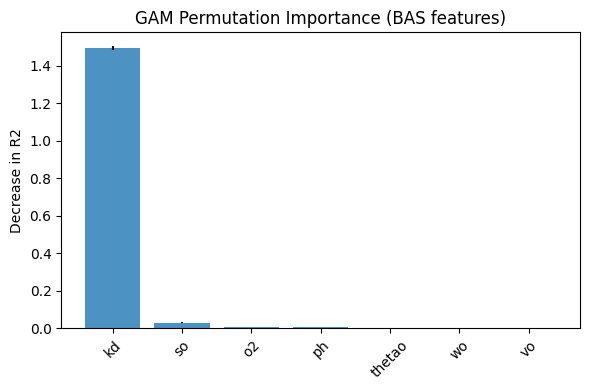

In [11]:
# ==========================
# BLOCK 11: Permutation Importance
# ==========================
print("\n=== Permutation Importance on Test Set (BAS-selected features) ===\n")

# Random Forest
rf_pi = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("RandomForest Permutation Importance (mean decrease in R2):")
for i in np.argsort(rf_pi.importances_mean)[::-1]:
    print(f"{SELECTED_FEATURES[i]:>5s}: {rf_pi.importances_mean[i]:.4f} ± {rf_pi.importances_std[i]:.4f}")
plot_perm_importance(rf_pi, SELECTED_FEATURES, "RandomForest Permutation Importance (BAS features)")

# XGBoost
xgb_pi = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("\nXGBoost Permutation Importance (mean decrease in R2):")
for i in np.argsort(xgb_pi.importances_mean)[::-1]:
    print(f"{SELECTED_FEATURES[i]:>5s}: {xgb_pi.importances_mean[i]:.4f} ± {xgb_pi.importances_std[i]:.4f}")
plot_perm_importance(xgb_pi, SELECTED_FEATURES, "XGBoost Permutation Importance (BAS features)")

# GAM
gam_pi = permutation_importance(
    gam,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("\nGAM Permutation Importance (mean decrease in R2):")
for i in np.argsort(gam_pi.importances_mean)[::-1]:
    print(f"{SELECTED_FEATURES[i]:>5s}: {gam_pi.importances_mean[i]:.4f} ± {gam_pi.importances_std[i]:.4f}")
plot_perm_importance(gam_pi, SELECTED_FEATURES, "GAM Permutation Importance (BAS features)")



=== SHAP for XGBoost (BAS-selected features) ===



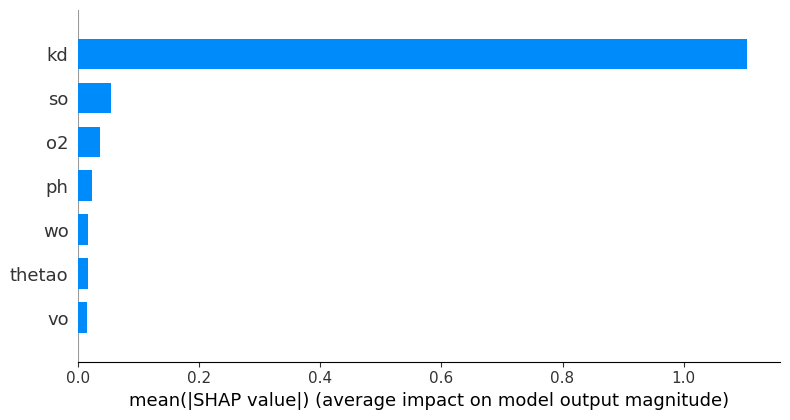

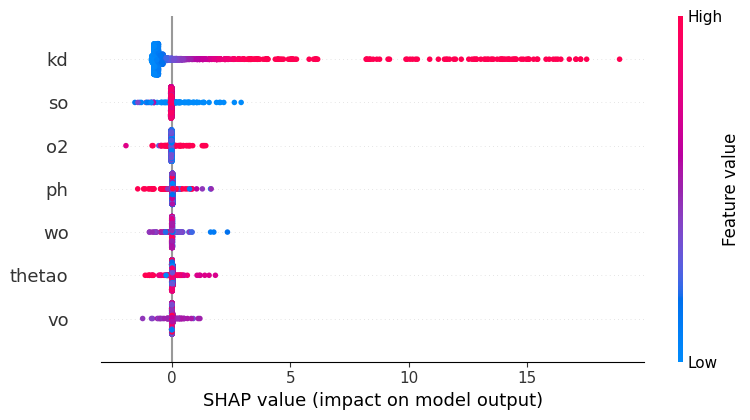

In [12]:
# ==========================
# BLOCK 12: SHAP for XGBoost
# ==========================
print("\n=== SHAP for XGBoost (BAS-selected features) ===\n")

# background for SHAP
n_bg = min(3000, X_train.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
bg_idx = rng.choice(X_train.shape[0], size=n_bg, replace=False)
X_bg = X_train[bg_idx, :]

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_bg)

# summary bar
shap.summary_plot(
    shap_values_xgb,
    X_bg,
    feature_names=SELECTED_FEATURES,
    plot_type="bar",
    show=True
)

# detailed scatter
shap.summary_plot(
    shap_values_xgb,
    X_bg,
    feature_names=SELECTED_FEATURES,
    show=True
)


In [13]:
# # ==========================
# # BLOCK 13: Save Models
# # ==========================
# os.makedirs("models", exist_ok=True)

# joblib.dump(rf,  "models/rf_model_bas.joblib")
# print("Saved: models/rf_model_bas.joblib")

# joblib.dump(xgb, "models/xgb_model_bas.joblib")
# print("Saved: models/xgb_model_bas.joblib")

# joblib.dump(gam, "models/gam_model_bas.joblib")
# print("Saved: models/gam_model_bas.joblib")

# ann.save("models/ann_model_bas.keras")
# print("Saved: models/ann_model_bas.keras")
